In [211]:
import network
import pandas as pd
import geopandas as gpd
import numpy as np
from datetime import datetime
import importlib
importlib.reload(network)
import matplotlib.pyplot as plt
import types
from IPython.display import clear_output
import os
import seaborn as sns
import osmnx as ox
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [59]:
n = network.Network()
n2 = network.Network()
ex = 'Data/Reseaux/ns_EX_PVR.graphml'
pot = 'Data/Reseaux/ns_POT_PVR.graphml'
trips_od18 = 'Data/od18_extraqit_20250123/od18_extraqit_20250123.csv'
stm_gtfs = 'Data/gtfs_stm/stops.txt'
signals_file = 'Data/feux-circulation.csv'

In [60]:
n.load_n_pot(pot)
n.load_n_ex(ex)
n.load_trips(trips_od18,source_crs=2950,potvel=False)
n2.load_n_pot(pot)
n2.load_n_ex(ex)
n2.load_trips(trips_od18,source_crs=2950,potvel=False)

In [61]:
stops = pd.read_csv(stm_gtfs)
metros = stops[stops['location_type']==1]
metros = gpd.GeoDataFrame(metros,geometry = gpd.points_from_xy(metros.stop_lon,metros.stop_lat),crs = 4326).to_crs(n.crs)
n.transit_stops=metros
n2.transit_stops=metros
signals = pd.read_csv(signals_file)

def add_traffic_signals(signals,network):
    signals = gpd.GeoDataFrame(signals,geometry = gpd.points_from_xy(signals.Longitude,signals.Latitude),crs = 4326).to_crs(n.crs)
    network.traffic_signals=signals
    near_traffic_signals = gpd.sjoin_nearest(n.n_pot_nodes,n.traffic_signals,max_distance=15,how = 'left')
    near_traffic_signals = near_traffic_signals[~near_traffic_signals.index.duplicated(keep='first')]
    network.n_pot_nodes['traffic_signals'] = near_traffic_signals.index_right.notna()


In [319]:
cost_reduction_factor = 0.7
np.random.seed(123)
n.reset_network()
n.add_edge_grades('Data/Elevation/output_AW3D30_32618_us.tif')
n.reset_routes()
n.reset_sample()
n.trips_within = n.trips_within[n.trips_within['mode']!='TC']
n.weight_network(cycleway_reduc_factor=cost_reduction_factor,grades=True)
n.sample_trips()
n.add_edge_bearing()
add_traffic_signals(signals,n)
n.get_personal_spatial_features(1,1)

n2.reset_network()
n2.add_edge_grades('Data/Elevation/output_AW3D30_32618_us.tif')
n2.reset_routes()
n2.reset_sample()
n2.trips_within = n2.trips_within[n2.trips_within['mode']!='TC']
n2.weight_network(cycleway_reduc_factor=1,grades=False)
n2.sample_trips()
n2.add_edge_bearing()
add_traffic_signals(signals,n2)
n2.get_personal_spatial_features(1,1)

In [ ]:
icp = 10
ltp = 6*icp
rtp = 2*icp
tsp = 2*icp
n.get_turn_penalties(n.n_pot,icp,ltp,rtp,tsp)
n2.get_turn_penalties(n2.n_pot,icp,ltp,rtp,tsp)


In [320]:
# n.compute_routes(n.n_pot)
# n.get_routes_edges(n.n_pot)
# n.compute_routes_summary(1,1,1,1,1,0)

n2.compute_routes(n2.n_pot)
n2.get_routes_edges(n2.n_pot)
n2.compute_routes_summary(1,1,1,1,1,0)

  0%|          | 0/3701 [00:00<?, ?it/s]

97.59524452850582 % of solved routes,  0.405295865982167  % of static routes


C:\Users\latitude\Desktop\Recherche\Algo_reseaux\network.py:386: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.000749039571367339 0.0009402173987779299 0.0021746165292307737 ...
 0.0013444111486658806 0.002367169554489256 0.0015935890888979743]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  self.routes_summary.loc[subsample_idxs,'generalized_benefit']+=((self.routes_summary.loc[subsample_idxs]['transit_min_dist']<proximity_dist)*beta_transit*np.std(self.routes_summary.loc[subsample_idxs,'generalized_benefit'])


In [322]:
n.routes_summary.loc[n2.routes_summary.index,'shortest_network_dist'] = n2.routes_summary['length']
n.routes_summary['BDR'] = n.routes_summary['length']/n.routes_summary['shortest_network_dist']
n.routes_summary['ABD'] = n.routes_summary['length']-n.routes_summary['shortest_network_dist']

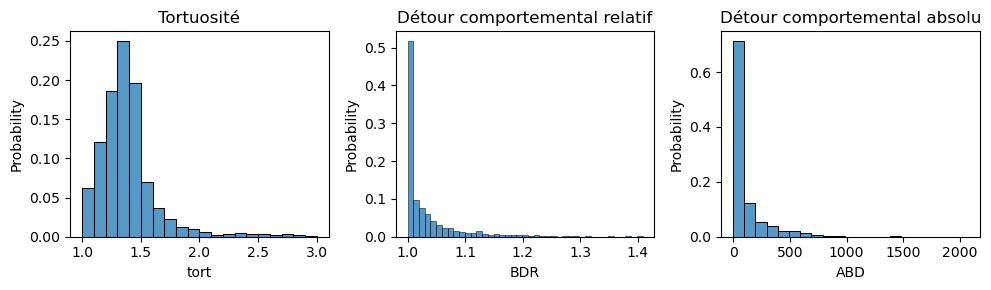

In [323]:
fig,ax = plt.subplots(1,3,figsize = (10,3))
ax[0].set_title('Tortuosité')
ax[1].set_title('Détour comportemental relatif')
ax[2].set_title('Détour comportemental absolu')

sns.histplot(n.routes_summary,x = 'tort',ax = ax[0],stat  ='probability',binwidth = 0.1,binrange = (1,3))
sns.histplot(n.routes_summary,x = 'BDR',ax = ax[1],stat  ='probability',binwidth = 0.01)
sns.histplot(n.routes_summary,x = 'ABD',ax = ax[2],stat  ='probability',binwidth = 100)
fig.tight_layout()
fig.savefig('Figures/detours_PVR.png')

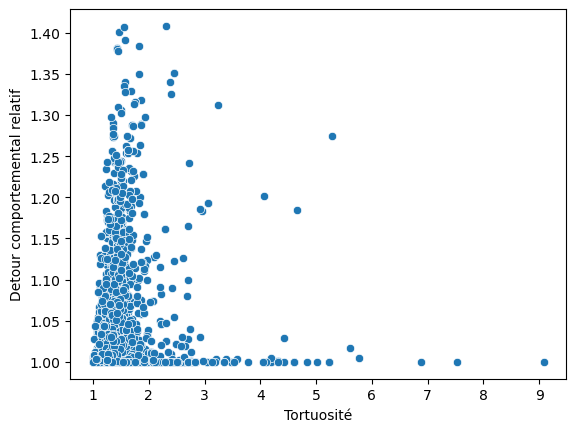

In [324]:
fig, ax = plt.subplots()

sns.scatterplot(n.routes_summary,x = 'tort',y = 'BDR',ax = ax)
ax.set_xlabel('Tortuosité')
ax.set_ylabel('Detour comportemental relatif')
fig.savefig('Figures/corr_detours_res_vol.png')

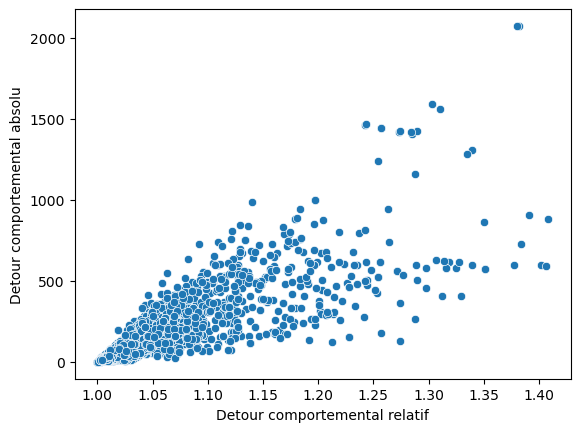

In [325]:
fig, ax = plt.subplots()

sns.scatterplot(n.routes_summary,x = 'BDR',y = 'ABD',ax = ax)
ax.set_xlabel('Detour comportemental relatif')
ax.set_ylabel('Detour comportemental absolu')
fig.savefig('Figures/corr_detours_abs_rel.png')

In [327]:
idx = n.routes_summary[(n.routes_summary.ABD<500)&(n.routes_summary.BDR>1.25)].sample().index.values[0]
m=n.all_routes_edges[n.all_routes_edges.route_number == idx].explore(tiles = 'CartoDB Positron')
n2.all_routes_edges[n2.all_routes_edges.route_number == idx].explore(color = 'red',m=m)
print(n.routes_summary.loc[idx][['tort','BDR','ABD']])
m

tort      5.287023
BDR       1.274114
ABD     130.108968
Name: 49381, dtype: object


In [328]:
scaler = StandardScaler().fit(n.routes_summary[['tort','length','ABD','BDR']].to_numpy())
scaled_data = scaler.transform(n.routes_summary[['tort','length','ABD','BDR']].to_numpy())

Ks =np.arange(1,20,1)
wcss = []
for K in Ks:
    kmeans = KMeans(n_clusters=K,random_state=123).fit(scaled_data)
    wss = ((scaled_data - kmeans.cluster_centers_[kmeans.labels_]) ** 2).sum()
    wcss.append(wss)

In [350]:
K = 5
kmeans = KMeans(n_clusters=K,random_state=123).fit(scaled_data)

cluster_name = dict({
    0 : 'Tu devrais marcher',
    1 : 'Long et bons trajets cyclables',
    2 : 'Courts trajets cyclables',
    3 : 'Détours acceptables',
    4 : 'Détours inacceptables',
    
    
})

n.routes_summary['cluster'] = kmeans.labels_
n.routes_summary['cluster_name'] = [cluster_name.get(key) for key in kmeans.labels_]

In [365]:
idx = n.routes_summary[n.routes_summary.cluster == 4].sample().index.values[0]
m=n.all_routes_edges[n.all_routes_edges.route_number == idx].explore(tiles = 'CartoDB Positron')
n2.all_routes_edges[n2.all_routes_edges.route_number == idx].explore(color = 'red',m=m)
print(n.routes_summary.loc[idx][['tort','BDR','ABD']])
m

tort      1.395946
BDR       1.198907
ABD     613.131821
Name: 36139, dtype: object


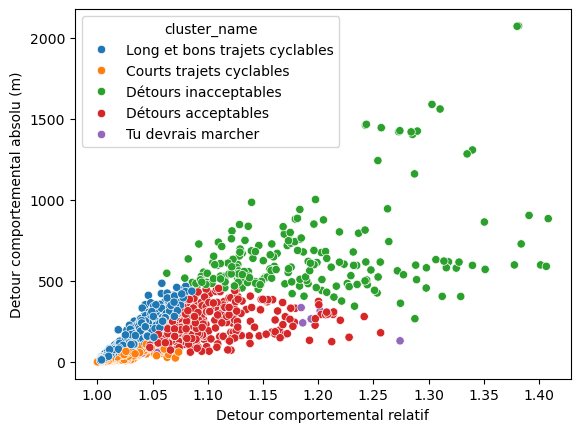

In [355]:
fig, ax = plt.subplots()

sns.scatterplot(n.routes_summary,x = 'BDR',y = 'ABD',ax = ax,hue = 'cluster_name')
ax.set_xlabel('Detour comportemental relatif')
ax.set_ylabel('Detour comportemental absolu (m)')
fig.savefig('Figures/clustering_trajets_detours.png')

In [332]:
n.routes_summary.groupby('cluster')[['tort','length','ABD','BDR']].median()

,tort,length,ABD,BDR
cluster,,,,
0,2.925384,1067.178466,0.000000,1.000000
1,1.337051,4175.300017,98.022311,1.024212
2,1.324703,1395.524280,1.172326,1.000857
3,1.424279,2493.840356,197.705277,1.090090
4,1.492863,4467.769883,581.060818,1.176212
